# Metodologia Design Science Research (DSR)

**Etapa de Pesquisa (Peffers et al., 2007):**
### 4. Demonstração (Demonstration)

**Objetivo Acadêmico:** Este notebook avalia modelos baseados em árvores de decisão e **Random Forest**. Estes modelos são fundamentais para capturar interações complexas entre as variáveis (ex: efeito conjunto de um feriado e uma proteína específica). Segundo a literatura de Industry 5.0, a robustez de modelos ensemble (Hevner et al., 2004) é um pilar para sistemas hiper-inteligentes de apoio à decisão.


# 07d - Modelagem: Árvores e Ensembles (RF, ExtraTrees)
Neste notebook, exploramos algoritmos baseados em árvores. 

**Vantagem**: Árvores não assumem linearidade e são ótimas para capturar mudanças bruscas (como a queda de consumo observada) através de quebras nos dados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import joblib
import os

# Configurações
BASE_SELECIONADA = '../data/base_features_selecionadas.csv'
TARGET = 'total_servido'

df = pd.read_csv(BASE_SELECIONADA)
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data')

print(f"📦 Base carregada: {df.shape[0]} registros.")

📦 Base carregada: 191 registros.


In [2]:
# Validação da Base 2023-2025
print(f"📊 Shape da base: {df.shape}")
print(f"📅 Período: {df['data'].min()} até {df['data'].max()}")

📊 Shape da base: (191, 52)
📅 Período: 2023-08-01 00:00:00 até 2025-08-22 00:00:00


In [3]:
# 1. Divisão Treino/Teste (Temporal)
train_size = int(len(df) * 0.8)
X_full = df.drop(columns=['data', TARGET])
y_full = df[TARGET]

X_train_full = X_full.iloc[:train_size]
y_train = y_full.iloc[:train_size]
X_test_full = X_full.iloc[train_size:]
y_test = y_full.iloc[train_size:]

# 2. Seleção de Variáveis (RFECV)
# Em árvores, o RFECV é ainda mais natural pois o próprio modelo avalia a importância.
print("🔄 Selecionando variáveis via RFECV...")
rf_selector = RandomForestRegressor(n_estimators=50, random_state=42)
selector = RFECV(estimator=rf_selector, step=1, cv=5, scoring='neg_mean_absolute_error')
selector.fit(X_train_full, y_train)

selected_features = X_full.columns[selector.support_].tolist()
print(f"✅ RFECV concluído! Número ideal de variáveis: {len(selected_features)}")
print(f"📌 Features: {selected_features}")

X_train = X_train_full[selected_features]
X_test = X_test_full[selected_features]

print(f"📈 Treino: {len(X_train)} dias | Teste: {len(X_test)} dias")

🔄 Selecionando variáveis via RFECV...
✅ RFECV concluído! Número ideal de variáveis: 5
📌 Features: ['total_reservas', 'erro_planejamento_ontem', 'reservas_media_movel_5d', 'total_reservas_lag_2', 'reservas_media_movel_3d']
📈 Treino: 152 dias | Teste: 39 dias


In [4]:
# Otimizando RF e ExtraTrees simultaneamente
models_params = {
    'RandomForest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5]
        }
    },
    'ExtraTrees': {
        'model': ExtraTreesRegressor(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5]
        }
    }
}

results = []
best_estimators = {}

for name, config in models_params.items():
    print(f"🔄 Otimizando {name}...")
    grid = GridSearchCV(config['model'], config['params'], cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    best_estimators[name] = best_model
    
    preds = best_model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append({
        'Modelo': name, 
        'MAE': mae, 
        'RMSE': rmse, 
        'R2': r2, 
        'Best_Params': grid.best_params_
    })

df_results = pd.DataFrame(results).sort_values('MAE')
display(df_results)

🔄 Otimizando RandomForest...
🔄 Otimizando ExtraTrees...


,Modelo,MAE,RMSE,R2,Best_Params
1,ExtraTrees,25.162375,31.794448,0.213392,"{'max_depth': 10, 'min_samples_split': 5, 'n_e..."
0,RandomForest,25.713409,33.775057,0.112337,"{'max_depth': 10, 'min_samples_split': 2, 'n_e..."


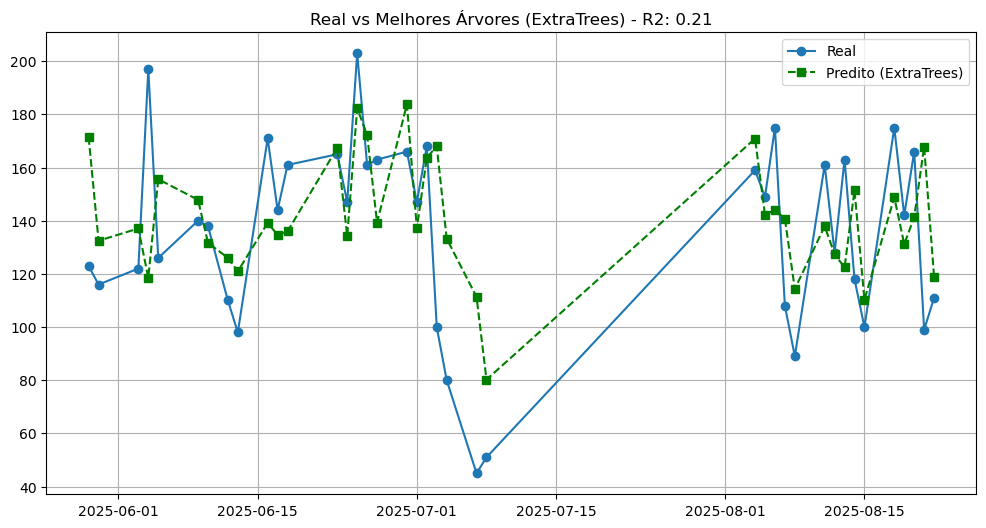

In [5]:
best_name = df_results.iloc[0]['Modelo']
best_model = best_estimators[best_name]
final_preds = best_model.predict(X_test)

plt.figure(figsize=(12, 6))
plt.plot(df.iloc[train_size:]['data'], y_test, label='Real', marker='o')
plt.plot(df.iloc[train_size:]['data'], final_preds, label=f'Predito ({best_name})', linestyle='--', marker='s', color='green')
plt.title(f"Real vs Melhores Árvores ({best_name}) - R2: {df_results.iloc[0]['R2']:.2f}")
plt.legend()
plt.grid(True)
plt.show()